# TEC 2D Mapping and Analysis Pipeline

This notebook performs end-to-end processing, analysis, and visualization of GNSS-derived ionospheric Total Electron Content (TEC) data.

### Tools Used:
- **Pandas** for data handling
- **Matplotlib** for visualization
- **NumPy** for numerical operations
- **GeoPandas** for spatial plotting
- **Datetime** for timestamp conversions

---

## 1. Read Raw TEC Data Files (.dat)
Load and clean GNSS-derived TEC observation files.

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os

def read_tec_data(file_path):
    """Read TEC data file and return a pandas DataFrame."""
    columns = ['Week', 'GPS_TOW', 'PRN', 'Az', 'Elv', 'L1CN0', 'S4', 'S4Cor', 
              'TEC30', 'TECRate30', 'L1LockTime', 'L2LockTime', 'L2CN0']
    
    df = pd.read_csv(file_path, names=columns, delimiter=',')
    
    # Convert relevant columns to numeric (you can add more if needed)
    for col in ['TEC30', 'TECRate30', 'GPS_TOW', 'Az', 'Elv', 'S4']:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    
    return df

# Path to the data directory
data_dir = "../Data/TEC_2D_Data/One_Day_Data"

# Get all .dat files
data_files = glob.glob(os.path.join(data_dir, "*.dat"))

for file_path in data_files:
    # Extract station ID from filename
    station_id = os.path.basename(file_path).split('_')[0]
    
    # Read data
    print(f"Processing station {station_id}...")
    data = read_tec_data(file_path)

    # Print basic statistics
    print(f"\nStation {station_id} Statistics:")
    print(f"Number of satellites: {len(data['PRN'].unique())}")
    print(f"Time span: {data['GPS_TOW'].max() - data['GPS_TOW'].min()} seconds")
    print(f"Average TEC: {data['TEC30'].mean():.2f} TECU")
    print(f"Max TEC: {data['TEC30'].max():.2f} TECU")
    print(f"Min TEC: {data['TEC30'].min():.2f} TECU")
    print("-" * 50)


Processing station 124...

Station 124 Statistics:
Number of satellites: 29
Time span: 86400.0 seconds
Average TEC: 33.91 TECU
Max TEC: 139.99 TECU
Min TEC: 0.00 TECU
--------------------------------------------------
Processing station 212...

Station 212 Statistics:
Number of satellites: 29
Time span: 86400.0 seconds
Average TEC: 32.39 TECU
Max TEC: 141.03 TECU
Min TEC: 0.00 TECU
--------------------------------------------------
Processing station 213...

Station 213 Statistics:
Number of satellites: 29
Time span: 86400.0 seconds
Average TEC: 32.18 TECU
Max TEC: 117.15 TECU
Min TEC: -4.22 TECU
--------------------------------------------------
Processing station 214...

Station 214 Statistics:
Number of satellites: 30
Time span: 86400.0 seconds
Average TEC: 31.82 TECU
Max TEC: 156.96 TECU
Min TEC: -9.90 TECU
--------------------------------------------------
Processing station 301...

Station 301 Statistics:
Number of satellites: 29
Time span: 86400.0 seconds
Average TEC: 52.32 TECU

## 2. Compute IPP Lat/Lon and ECA using Geometric Formulas

### ✅ **Formulas** 

1. **ECA**:

   $$
   \text{eca} = \frac{\pi}{2} - \text{el}_{\text{sat}} - \sin^{-1} \left( \frac{r_e \cdot \cos(\text{el}_{\text{sat}})}{r_e + h_I} \right)
   $$

2. **IPP\_lat**:

   $$
   \text{IPP}_{\text{lat}} = \sin^{-1} \left( \sin(R_{\text{lat}})\cos(\text{eca}) + \cos(R_{\text{lat}})\sin(\text{eca})\cos(\text{az}_{\text{sat}}) \right)
   $$

3. **IPP\_lon**:

   $$
   \text{IPP}_{\text{lon}} = R_{\text{lon}} + \frac{\sin^{-1}(\sin(\text{eca}) \cdot \sin(\text{az}_{\text{sat}}))}{\cos(\text{IPP}_{\text{lat}})}
   $$

### 📌 Required Parameters

* `el_sat` → `Elv` column (in degrees) → convert to radians
* `az_sat` → `Az` column (in degrees) → convert to radians
* `R_lat`, `R_lon` → receiver (station) lat/lon (constants per file or passed externally)
* `r_e` = 6371 km (mean Earth radius)
* `h_I` = 350 km (typical ionospheric shell height)

---

In [24]:
import pandas as pd
import numpy as np
import glob, os

def read_tec_data(file_path):
    columns = ['Week', 'GPS_TOW', 'PRN', 'Az', 'Elv', 'L1CN0', 'S4', 'S4Cor', 
               'TEC30', 'TECRate30', 'L1LockTime', 'L2LockTime', 'L2CN0']
    df = pd.read_csv(file_path, names=columns, delimiter=',', skiprows=1)
    for col in ['Az', 'Elv', 'TEC30', 'TECRate30', 'GPS_TOW', 'S4']:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    return df

def compute_ipp(df, R_lat_deg, R_lon_deg, h_I=350, r_e=6371):
    # Convert degrees to radians
    R_lat = np.radians(R_lat_deg)
    R_lon = np.radians(R_lon_deg)
    el = np.radians(df['Elv'])
    az = np.radians(df['Az'])

    # ECA calculation
    term = (r_e * np.cos(el)) / (r_e + h_I)
    eca = (np.pi / 2) - el - np.arcsin(term)

    # IPP latitude
    IPP_lat = np.arcsin(np.sin(R_lat) * np.cos(eca) + 
                        np.cos(R_lat) * np.sin(eca) * np.cos(az))

    # IPP longitude
    delta_lon = np.arcsin(np.sin(eca) * np.sin(az)) / np.cos(IPP_lat)
    IPP_lon = R_lon + delta_lon

    # Convert radians to degrees
    df['ECA'] = np.degrees(eca)
    df['IPP_lat'] = np.degrees(IPP_lat)
    df['IPP_lon'] = np.degrees(IPP_lon)
    return df

# ---- MAIN SCRIPT ----
data_dir = "../Data/TEC_2D_Data/One_Day_Data"
output_dir = "../Data/GenData/Processed_TEC_with_IPP"
os.makedirs(output_dir, exist_ok=True)

data_files = glob.glob(os.path.join(data_dir, "*.dat"))

# 🔧 You must set the receiver's latitude and longitude for each station
station_coords = {
    "124": (31.10, 77.17),   # Shimla
    "212": (28.61, 77.20),   # Delhi
    "213": (26.24, 73.02),   # Jodhpur
    "214": (26.85, 80.95),   # Lucknow
    "301": (26.70, 88.35),   # Bagdogra
    "302": (26.14, 91.77),   # Guwahati
    "305": (23.72, 92.72),   # Aizawl
    "306": (23.03, 72.58),   # Ahmedabad
    "307": (23.25, 77.41),   # Bhopal
    "308": (21.25, 81.63),   # Raipur
    "309": (22.57, 88.36),   # Kolkata
    "310": (19.07, 72.87),   # Mumbai
    "311": (17.39, 78.49),   # Hyderabad
    "313": (17.69, 83.22),   # Visakhapatnam
    "315": (12.97, 77.59),   # Bangalore
    "316": (8.49, 76.95),    # Trivandrum
}

for file_path in data_files:
    station_id = os.path.basename(file_path).split('_')[0]
    print(f"Processing station {station_id}...")

    data = read_tec_data(file_path)

    # Get station lat/lon or default
    R_lat, R_lon = station_coords.get(station_id, (23.0, 78.0))  # default to MP center

    # Compute IPP and ECA
    data = compute_ipp(data, R_lat, R_lon)

    # Save to new directory
    new_file = os.path.join(output_dir, f"{station_id}_with_IPP.csv")
    data.to_csv(new_file, index=False)
    print(f"Saved processed file to: {new_file}")


Processing station 124...
Saved processed file to: ../Data/GenData/Processed_TEC_with_IPP\124_with_IPP.csv
Processing station 212...
Saved processed file to: ../Data/GenData/Processed_TEC_with_IPP\212_with_IPP.csv
Processing station 213...
Saved processed file to: ../Data/GenData/Processed_TEC_with_IPP\213_with_IPP.csv
Processing station 214...
Saved processed file to: ../Data/GenData/Processed_TEC_with_IPP\214_with_IPP.csv
Processing station 301...
Saved processed file to: ../Data/GenData/Processed_TEC_with_IPP\301_with_IPP.csv
Processing station 302...
Saved processed file to: ../Data/GenData/Processed_TEC_with_IPP\302_with_IPP.csv
Processing station 305...
Saved processed file to: ../Data/GenData/Processed_TEC_with_IPP\305_with_IPP.csv
Processing station 306...
Saved processed file to: ../Data/GenData/Processed_TEC_with_IPP\306_with_IPP.csv
Processing station 307...
Saved processed file to: ../Data/GenData/Processed_TEC_with_IPP\307_with_IPP.csv
Processing station 308...
Saved proce

## 3. Convert GPS Time of Week to UTC and IST

GPS Time (since 2005-04-03) → UTC → IST

In [25]:
import pandas as pd
import numpy as np
import glob
import os
from datetime import datetime, timedelta, timezone

# Constants
GPS_EPOCH = datetime(1980, 1, 6, tzinfo=timezone.utc)
LEAP_SECONDS = 18  # As of 2024 (may update if GPS time advances)

def gps_to_utc(gps_week, tow_seconds):
    """Convert GPS Week + Time of Week to UTC datetime."""
    gps_time = GPS_EPOCH + timedelta(weeks=gps_week, seconds=tow_seconds)
    utc_time = gps_time - timedelta(seconds=LEAP_SECONDS)
    return utc_time

def utc_to_ist(utc_dt):
    """Convert UTC datetime to IST datetime."""
    return utc_dt + timedelta(hours=5, minutes=30)

# Paths
input_dir = "../Data/GenData/Processed_TEC_with_IPP"
output_dir = "../Data/GenData/Processed_TEC_with_IPP_Timestamps"
os.makedirs(output_dir, exist_ok=True)

# Process all files
for file_path in glob.glob(os.path.join(input_dir, "*.csv")):
    df = pd.read_csv(file_path)
    
    if df.empty:
        continue
    
    print(f"Processing timestamps for {os.path.basename(file_path)}...")

    # Compute UTC and IST datetime columns
    df['UTC_time'] = [gps_to_utc(w, tow) for w, tow in zip(df['Week'], df['GPS_TOW'])]
    df['IST_time'] = [utc_to_ist(utc) for utc in df['UTC_time']]
    
    # Save to new file
    filename = os.path.basename(file_path)
    df.to_csv(os.path.join(output_dir, filename), index=False)

    print(f"✅ Saved: {filename} with UTC and IST columns added.")


Processing timestamps for 124_with_IPP.csv...
✅ Saved: 124_with_IPP.csv with UTC and IST columns added.
Processing timestamps for 212_with_IPP.csv...
✅ Saved: 212_with_IPP.csv with UTC and IST columns added.
Processing timestamps for 213_with_IPP.csv...
✅ Saved: 213_with_IPP.csv with UTC and IST columns added.
Processing timestamps for 214_with_IPP.csv...
✅ Saved: 214_with_IPP.csv with UTC and IST columns added.
Processing timestamps for 301_with_IPP.csv...
✅ Saved: 301_with_IPP.csv with UTC and IST columns added.
Processing timestamps for 302_with_IPP.csv...
✅ Saved: 302_with_IPP.csv with UTC and IST columns added.
Processing timestamps for 305_with_IPP.csv...
✅ Saved: 305_with_IPP.csv with UTC and IST columns added.
Processing timestamps for 306_with_IPP.csv...
✅ Saved: 306_with_IPP.csv with UTC and IST columns added.
Processing timestamps for 307_with_IPP.csv...
✅ Saved: 307_with_IPP.csv with UTC and IST columns added.
Processing timestamps for 308_with_IPP.csv...
✅ Saved: 308_with_

## 4. Visualization of TEC, S4, TEC Rate, and Sky Plots
- TEC vs Time
- S4 Scintillation vs Time
- Polar Sky Plot (Azimuth vs Elevation)
- TEC Rate vs Time

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.dates as mdates
import glob
import os
import numpy as np

# Function to read data and apply elevation filter
def read_tec_data(file_path):
    df = pd.read_csv(file_path, parse_dates=['IST_time'])  # Parse IST_time as datetime
    
    # Apply elevation cutoff
    df = df[df['Elv'] >= 25]
    
    # Convert required columns to numeric
    for col in ['Az', 'Elv', 'TEC30', 'TECRate30', 'S4']:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    
    return df

# Function to create and save all 4 plots
def plot_tec_data(data, station_id, base_output="../Output"):
    unique_prns = sorted(data['PRN'].unique())
    cmap = cm.get_cmap('tab20', len(unique_prns))

    # Create output subfolders
    os.makedirs(os.path.join(base_output, "TEC_TimeSeries"), exist_ok=True)
    os.makedirs(os.path.join(base_output, "S4_Scintillation"), exist_ok=True)
    os.makedirs(os.path.join(base_output, "Sky_Plot"), exist_ok=True)
    os.makedirs(os.path.join(base_output, "TEC_Rate"), exist_ok=True)

    # ---------- Plot 1: TEC Time Series ----------
    fig1, ax1 = plt.subplots(figsize=(10, 6))
    for i, prn in enumerate(unique_prns):
        prn_data = data[data['PRN'] == prn]
        ax1.scatter(prn_data['IST_time'], prn_data['TEC30'], label=f'PRN {prn}', s=12, color=cmap(i))
    ax1.set_title(f'TEC Values Over Time - Station {station_id}')
    ax1.set_xlabel('IST Time')
    ax1.set_ylabel('TEC (TECU)')
    ax1.set_ylim(0, 120)
    ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left', markerscale=1.2)
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    ax1.xaxis.set_major_locator(mdates.HourLocator(interval=1))
    fig1.autofmt_xdate()
    fig1.tight_layout()
    fig1.savefig(os.path.join(base_output, "TEC_TimeSeries", f"{station_id}_tec.png"), dpi=300, bbox_inches='tight')
    plt.close(fig1)

    # ---------- Plot 2: S4 Scintillation ----------
    fig2, ax2 = plt.subplots(figsize=(10, 6))
    for i, prn in enumerate(unique_prns):
        prn_data = data[data['PRN'] == prn]
        ax2.scatter(prn_data['IST_time'], prn_data['S4'], label=f'PRN {prn}', s=12, color=cmap(i))
    ax2.set_title(f'S4 Scintillation Index - Station {station_id}')
    ax2.set_xlabel('IST Time')
    ax2.set_ylabel('S4 Index')
    ax2.set_ylim(0, 1.5)
    ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left', markerscale=1.2)
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    ax2.xaxis.set_major_locator(mdates.HourLocator(interval=1))
    fig2.autofmt_xdate()
    fig2.tight_layout()
    fig2.savefig(os.path.join(base_output, "S4_Scintillation", f"{station_id}_s4.png"), dpi=300, bbox_inches='tight')
    plt.close(fig2)

    # ---------- Plot 3: Polar Sky Plot ----------
    fig3 = plt.figure(figsize=(8, 8))
    ax3 = fig3.add_subplot(111, polar=True)
    az_rad = np.radians(data['Az'])
    el_adj = 90 - data['Elv']
    sc = ax3.scatter(az_rad, el_adj, c=data['TEC30'], cmap='jet', s=20)
    ax3.set_title(f'Polar Sky Plot - Station {station_id}', pad=20)
    plt.colorbar(sc, ax=ax3, label='TEC (TECU)', pad=0.1)
    ax3.set_theta_zero_location('N')
    ax3.set_theta_direction(-1)
    ax3.set_rgrids([0, 30, 60], labels=["90°", "60°", "30°"], angle=22.5)
    ax3.set_thetagrids(range(0, 360, 45), labels=[f'{ang}°' for ang in range(0, 360, 45)])
    fig3.tight_layout()
    fig3.savefig(os.path.join(base_output, "Sky_Plot", f"{station_id}_sky.png"), dpi=300, bbox_inches='tight')
    plt.close(fig3)

    # ---------- Plot 4: TEC Rate ----------
    fig4, ax4 = plt.subplots(figsize=(10, 6))
    for i, prn in enumerate(unique_prns):
        prn_data = data[data['PRN'] == prn]
        ax4.scatter(prn_data['IST_time'], prn_data['TECRate30'], label=f'PRN {prn}', s=12, color=cmap(i))
    ax4.set_title(f'TEC Rate - Station {station_id}')
    ax4.set_xlabel('IST Time')
    ax4.set_ylabel('TEC Rate (TECU/min)')
    ax4.set_ylim(-1.5, 1.5)
    ax4.legend(bbox_to_anchor=(1.05, 1), loc='upper left', markerscale=1.2)
    ax4.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    ax4.xaxis.set_major_locator(mdates.HourLocator(interval=1))
    fig4.autofmt_xdate()
    fig4.tight_layout()
    fig4.savefig(os.path.join(base_output, "TEC_Rate", f"{station_id}_tec_rate.png"), dpi=300, bbox_inches='tight')
    plt.close(fig4)

# -----------------------------
# Main script
# -----------------------------
data_dir = "../Data/GenData/Processed_TEC_with_IPP_Timestamps"
data_files = glob.glob(os.path.join(data_dir, "*.csv"))

for file_path in data_files:
    station_id = os.path.basename(file_path).split('_')[0]
    print(f"Processing station {station_id}...")
    
    data = read_tec_data(file_path)
    
    if data.empty:
        print(f"⚠️  Station {station_id}: No valid data after elevation filter. Skipping...\n" + "-"*50)
        continue

    # Generate plots
    plot_tec_data(data, station_id)
    
    # Print stats
    print(f"\nStation {station_id} Statistics:")
    print(f"Number of satellites: {len(data['PRN'].unique())}")
    print(f"Time span: {data['IST_time'].min()} to {data['IST_time'].max()}")
    print(f"Average TEC: {data['TEC30'].mean():.2f} TECU")
    print(f"Max TEC: {data['TEC30'].max():.2f} TECU")
    print(f"Min TEC: {data['TEC30'].min():.2f} TECU")
    print("-" * 50)


Processing station 124...


C:\Users\hp\AppData\Local\Temp\ipykernel_10452\838001040.py:25: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab20', len(unique_prns))



Station 124 Statistics:
Number of satellites: 28
Time span: 2005-04-03 05:29:42+00:00 to 2005-04-04 05:29:42+00:00
Average TEC: 30.38 TECU
Max TEC: 113.64 TECU
Min TEC: 1.67 TECU
--------------------------------------------------
Processing station 212...


C:\Users\hp\AppData\Local\Temp\ipykernel_10452\838001040.py:25: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab20', len(unique_prns))



Station 212 Statistics:
Number of satellites: 28
Time span: 2005-04-03 05:29:42+00:00 to 2005-04-04 05:29:42+00:00
Average TEC: 28.78 TECU
Max TEC: 114.47 TECU
Min TEC: 0.95 TECU
--------------------------------------------------
Processing station 213...


...


Station 313 Statistics:
Number of satellites: 28
Time span: 2005-04-03 05:29:42+00:00 to 2005-04-04 05:29:42+00:00
Average TEC: 47.26 TECU
Max TEC: 121.88 TECU
Min TEC: 9.12 TECU
--------------------------------------------------
Processing station 315...


C:\Users\hp\AppData\Local\Temp\ipykernel_10452\838001040.py:25: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab20', len(unique_prns))



Station 315 Statistics:
Number of satellites: 28
Time span: 2005-04-03 05:29:42+00:00 to 2005-04-04 05:29:42+00:00
Average TEC: 31.43 TECU
Max TEC: 92.40 TECU
Min TEC: -3.49 TECU
--------------------------------------------------
Processing station 316...


C:\Users\hp\AppData\Local\Temp\ipykernel_10452\838001040.py:25: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab20', len(unique_prns))



Station 316 Statistics:
Number of satellites: 28
Time span: 2005-04-03 05:29:42+00:00 to 2005-04-04 05:29:42+00:00
Average TEC: 40.59 TECU
Max TEC: 97.87 TECU
Min TEC: 7.99 TECU
--------------------------------------------------


# [TODO] - IPP Plot from all stations on India Map

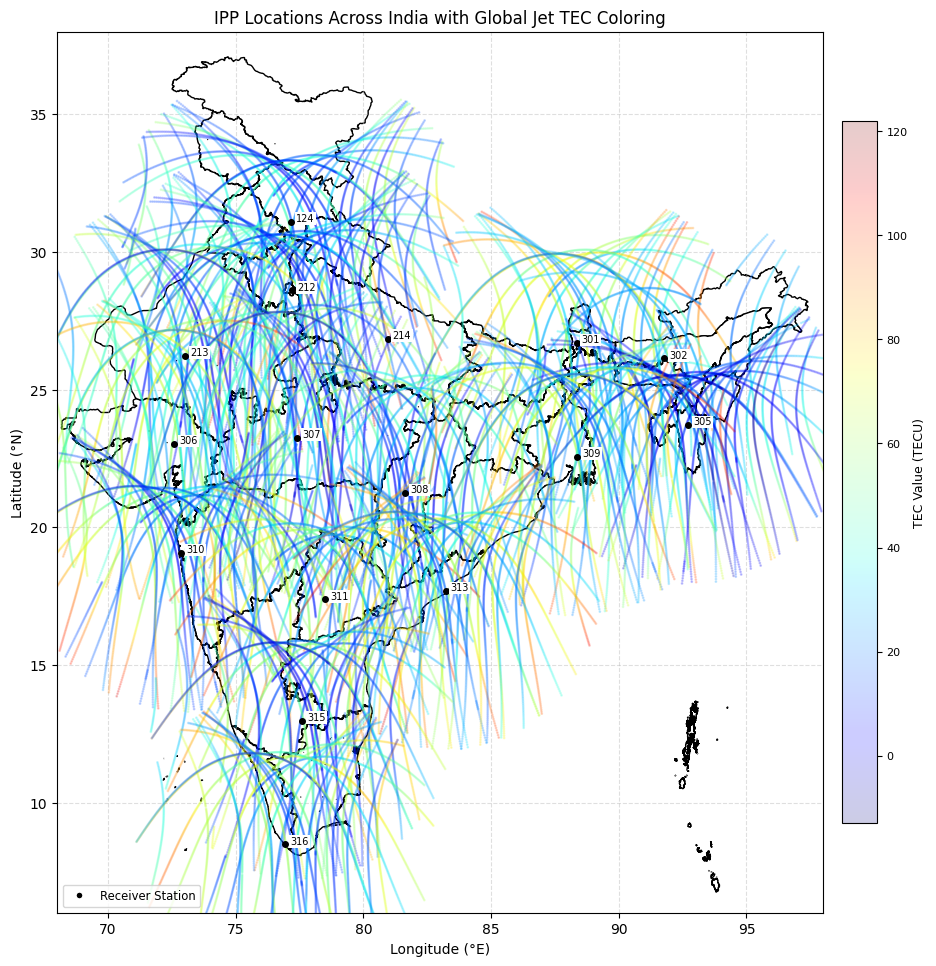

In [14]:
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import glob
import os
import numpy as np
from matplotlib.colors import Normalize
from matplotlib.lines import Line2D
from matplotlib.cm import ScalarMappable

# Load India shapefile
shapefile_path = "../Data/shapefiles/STATE_BOUNDARY.shp"
gdf = gpd.read_file(shapefile_path)
if gdf.crs is None or gdf.crs.to_epsg() != 4326:
    gdf = gdf.to_crs(epsg=4326)

# Updated station coordinates (matched to 16 site IDs)
station_coords = {
    "124": (31.10, 77.17),   # Shimla
    "212": (28.61, 77.20),   # Delhi
    "213": (26.24, 73.02),   # Jodhpur
    "214": (26.85, 80.95),   # Lucknow
    "301": (26.70, 88.35),   # Bagdogra
    "302": (26.14, 91.77),   # Guwahati
    "305": (23.72, 92.72),   # Aizawl
    "306": (23.03, 72.58),   # Ahmedabad
    "307": (23.25, 77.41),   # Bhopal
    "308": (21.25, 81.63),   # Raipur
    "309": (22.57, 88.36),   # Kolkata
    "310": (19.07, 72.87),   # Mumbai
    "311": (17.39, 78.49),   # Hyderabad
    "313": (17.69, 83.22),   # Visakhapatnam
    "315": (12.97, 77.59),   # Bangalore
    "316": (8.49, 76.95),    # Trivandrum
}

# Gather all IPP points and their TEC values
ipp_data_dir = "../Data/GenData/Processed_TEC_with_IPP_Timestamps"
ipp_files = glob.glob(os.path.join(ipp_data_dir, "*.csv"))

all_df = []
for file in ipp_files:
    df = pd.read_csv(file)
    df = df.dropna(subset=['IPP_lat', 'IPP_lon', 'TEC30'])
    df = df[df['Elv'] >= 25]  # Apply elevation cutoff
    all_df.append(df[['IPP_lat', 'IPP_lon', 'TEC30']])

combined_df = pd.concat(all_df, ignore_index=True)

# Plot
fig, ax = plt.subplots(figsize=(10, 12))
gdf.plot(ax=ax, color='white', edgecolor='black')

norm = Normalize(vmin=combined_df['TEC30'].min(), vmax=combined_df['TEC30'].max())
cmap = plt.cm.jet
sc = ax.scatter(combined_df['IPP_lon'], combined_df['IPP_lat'], c=combined_df['TEC30'], 
                cmap=cmap, norm=norm, s=1, alpha=0.2, zorder=2)

# Plot station markers
for station, (lat, lon) in station_coords.items():
    ax.plot(lon, lat, 'ko', markersize=4, zorder=4, label='_nolegend_')
    ax.text(lon + 0.2, lat, station, fontsize=7, color='black',
            bbox=dict(facecolor='white', edgecolor='none', pad=1), zorder=5)

# Add shared colorbar
cbar = plt.colorbar(sc, ax=ax, orientation='vertical', shrink=0.6, pad=0.02)
cbar.set_label('TEC Value (TECU)', fontsize=9)
cbar.ax.tick_params(labelsize=8)

# Add custom legend
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Receiver Station', markerfacecolor='black', markersize=5),
]
ax.legend(handles=legend_elements, loc='lower left', fontsize='small')

# Final plot aesthetics
ax.set_title("IPP Locations Across India with Global Jet TEC Coloring")
ax.set_xlabel("Longitude (°E)")
ax.set_ylabel("Latitude (°N)")
ax.set_xlim(68, 98)
ax.set_ylim(6, 38)
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()

# Save the output
plt.savefig("../Output/IPP_Map_GlobalJet_TECColor.png", dpi=300, bbox_inches='tight')
plt.show()


## 5. Plot ROI Grid Boxes on Indian Map
Higlights predefined ranges/zones for analysis over Indian region

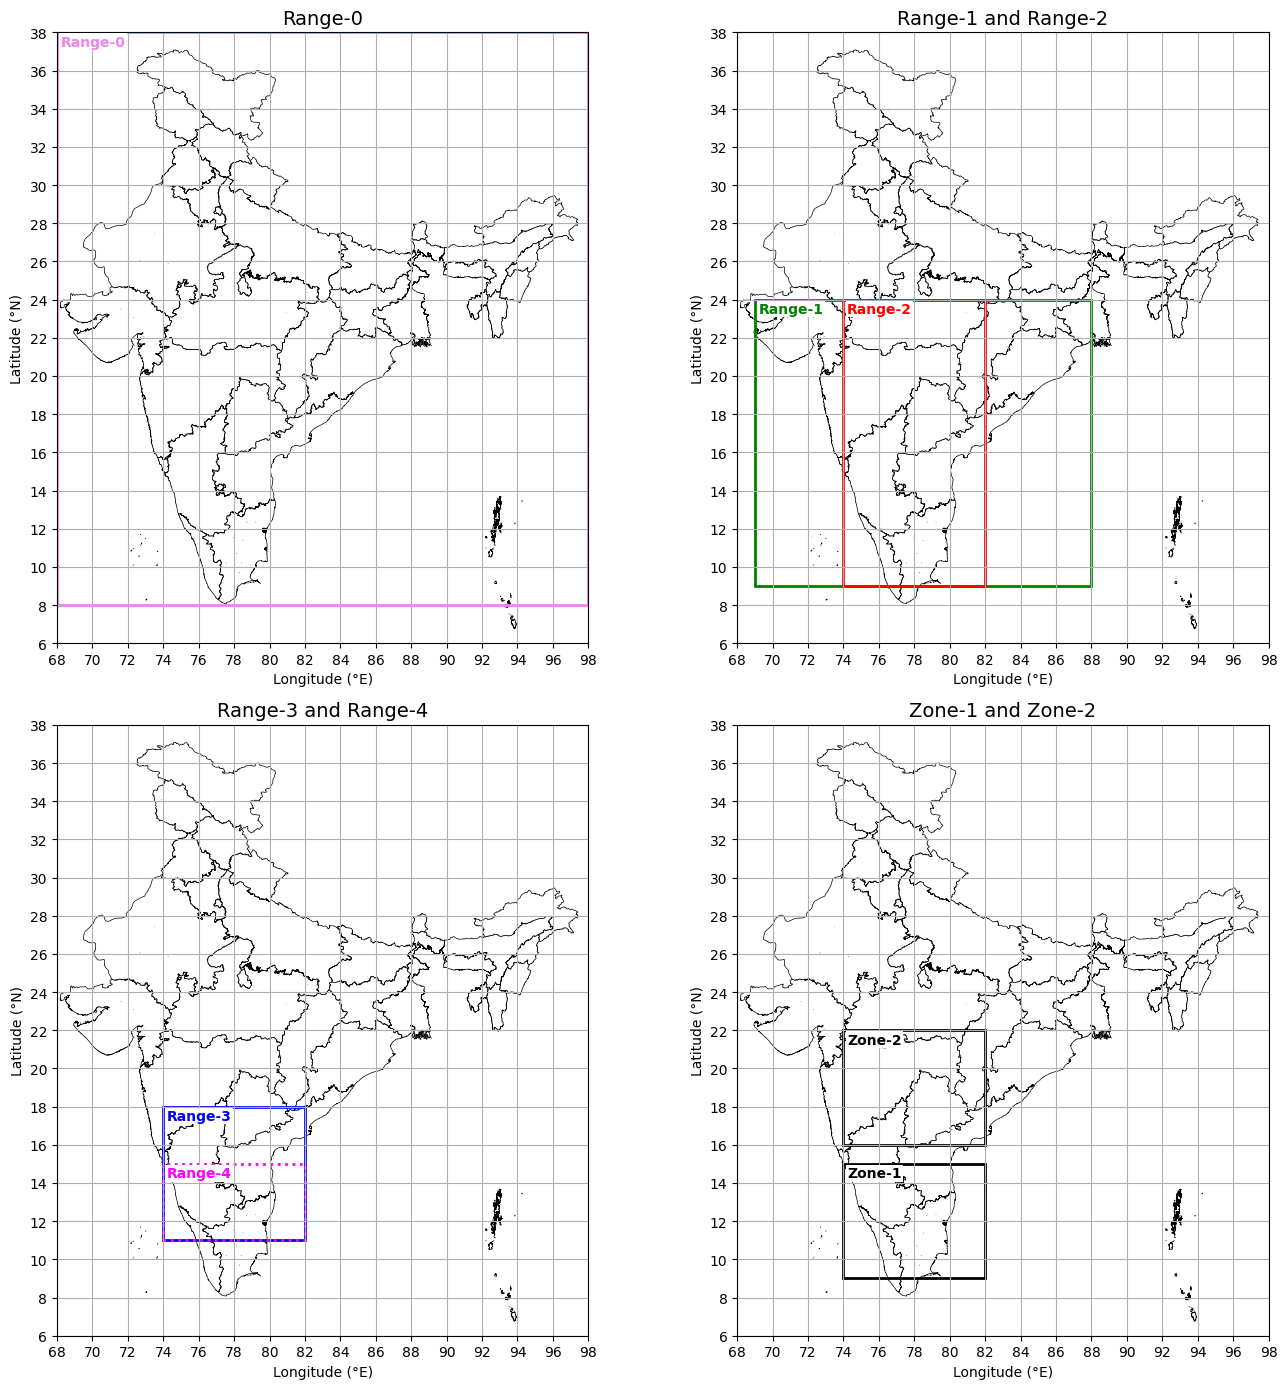

In [2]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import matplotlib.ticker as mticker

# Load and reproject the state-level shapefile of India to WGS84
shapefile_path = "../Data/shapefiles/STATE_BOUNDARY.shp"
gdf = gpd.read_file(shapefile_path)

# Ensure CRS is WGS84 (lat/lon)
if gdf.crs is None or gdf.crs.to_epsg() != 4326:
    gdf = gdf.to_crs(epsg=4326)

# Define bounding boxes: (lon_min, lon_max, lat_min, lat_max)
regions = {
    'Range-0': {'bounds': (68, 98, 8, 38), 'color': 'violet'},
    'Range-1': {'bounds': (69, 88, 9, 24), 'color': 'green'},
    'Range-2': {'bounds': (74, 82, 9, 24), 'color': 'red'},
    'Range-3': {'bounds': (74, 82, 11, 18), 'color': 'blue'},
    'Range-4': {'bounds': (74, 82, 11, 15), 'color': 'magenta', 'linestyle': 'dotted'},
    'Zone-1':  {'bounds': (74, 82, 9, 15), 'color': 'black'},
    'Zone-2':  {'bounds': (74, 82, 16, 22), 'color': 'black'},
}

# Subplot layout
fig, axs = plt.subplots(2, 2, figsize=(14, 14))
axs = axs.flatten()

subplot_regions = [
    ['Range-0'],
    ['Range-1', 'Range-2'],
    ['Range-3', 'Range-4'],
    ['Zone-1', 'Zone-2']
]
titles = [
    "Range-0",
    "Range-1 and Range-2",
    "Range-3 and Range-4",
    "Zone-1 and Zone-2"
]

for ax, group, title in zip(axs, subplot_regions, titles):
    # Plot base India map
    gdf.plot(ax=ax, color='white', edgecolor='black', linewidth=0.5)

    # Plot bounding boxes and labels
    for region in group:
        lon_min, lon_max, lat_min, lat_max = regions[region]['bounds']
        width = lon_max - lon_min
        height = lat_max - lat_min
        linestyle = regions[region].get('linestyle', 'solid')
        
        # Draw rectangle
        rect = Rectangle((lon_min, lat_min), width, height,
                         linewidth=2, edgecolor=regions[region]['color'],
                         facecolor='none', linestyle=linestyle)
        ax.add_patch(rect)
        
        # Add label at top-left corner
        ax.text(lon_min + 0.2, lat_max - 0.7, region,
                fontsize=10, color=regions[region]['color'],
                weight='bold', bbox=dict(facecolor='white', edgecolor='none', pad=1))

    # Set axis limits and labels
    ax.set_xlim(68, 98)
    ax.set_ylim(6, 38)
    ax.set_title(title, fontsize=14)
    ax.set_xlabel("Longitude (°E)")
    ax.set_ylabel("Latitude (°N)")

    # Mark ticks at every 2 degrees
    ax.xaxis.set_major_locator(mticker.MultipleLocator(2))
    ax.yaxis.set_major_locator(mticker.MultipleLocator(2))
    ax.grid(True)

plt.tight_layout()
plt.show()
